## Machine Learning for Industrial Predictive Maintenance

## Problem Statement
#### "Unplanned machine failures cost manufacturers downtime and money. This project predicts machine failure in advance so maintenance can be scheduled proactively."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

## 1. Exploratory Data Analysis (EDA)

In [2]:
data=pd.read_csv("ai4i2020.csv")

In [3]:
data.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
data.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

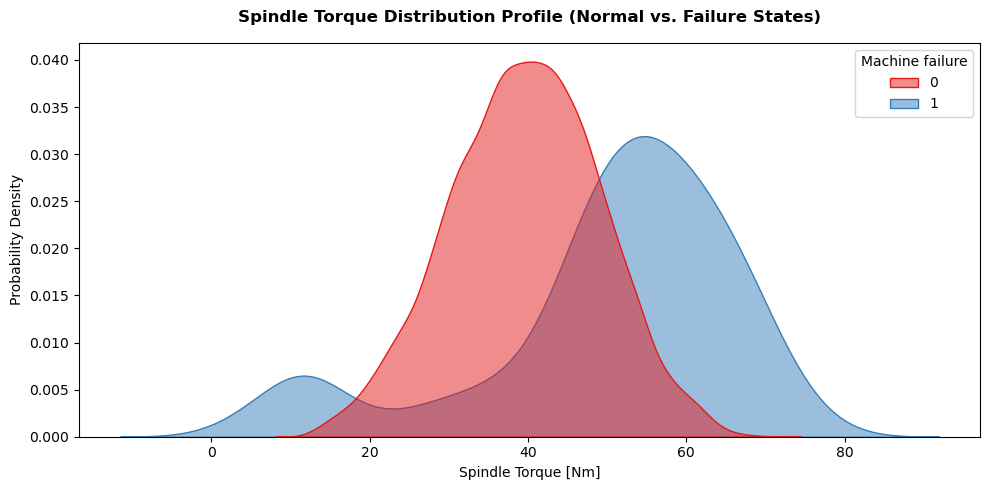

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Spindle Torque Density Distribution Analysis
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=data, x='Torque [Nm]', hue='Machine failure', 
    fill=True, palette='Set1', common_norm=False, alpha=0.5
)
plt.title('Spindle Torque Distribution Profile (Normal vs. Failure States)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Spindle Torque [Nm]', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.tight_layout()
plt.show()

**Normal Operation (Red):** Sharp tower peaking tightly at **35–45 Nm**, representing stable, safe factory runtimes.
**Machine Failure (Blue):** Flat, wide curve splitting into two dangerous extremes:
1. **Low Torque (<20 Nm):** Mechanical breakdown where parts snap or shear off, dropping engine load to zero.
2. **High Torque (>60 Nm):** Component overstrain where tools jam or seize, spiking load until the system cuts out.

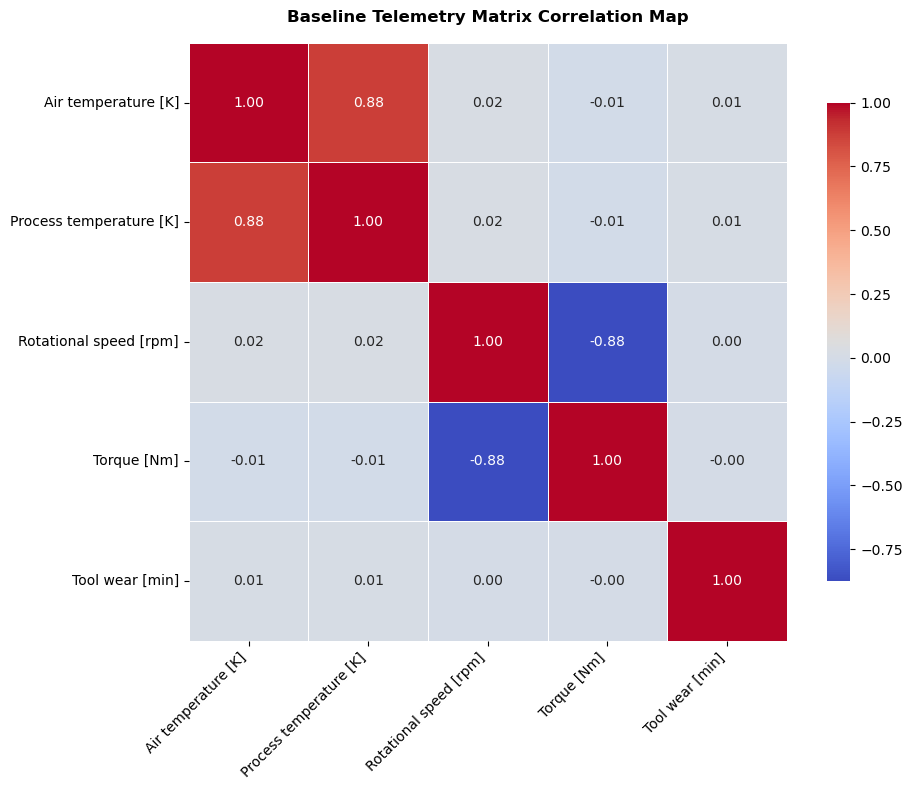

In [8]:
plt.figure(figsize=(10, 8))

# Isolate standard numeric features from the dataset
numeric_features = [
    'Air temperature [K]', 'Process temperature [K]', 
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]
correlation_matrix = data[numeric_features].corr()

sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",
    linewidths=0.5, square=True, cbar_kws={"shrink": .8}
)
plt.title('Baseline Telemetry Matrix Correlation Map', fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Thermal Collinearity:** Severe **0.88** overlap between `Air temperature` and `Process temperature`.Passing both directly causes model redundancy.

**Mechanical Inversion:** Strong inverse relationship (**-0.88**) between `Rotational speed` and `Torque` (as load increases, speed drops).

**Engineering Fix:** Validates why we create unified features like Thermal Delta ($\Delta T$) and Spindle Power to eliminate data overlap.

--- Class Distribution ---
Normal Operation (Class 0): 9661 records (96.61%)
Failure Case (Class 1): 339 records (3.39%)


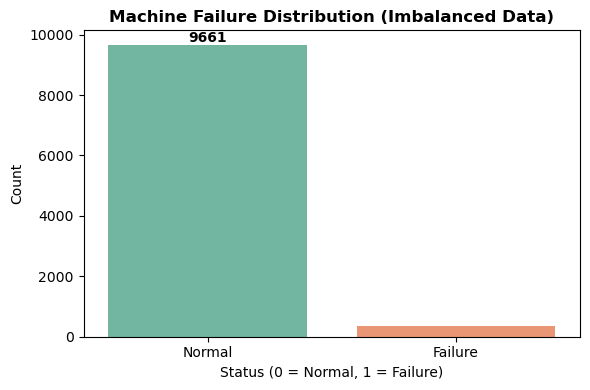

In [9]:
counts = data['Machine failure'].value_counts()
pcts = data['Machine failure'].value_counts(normalize=True) * 100
print("--- Class Distribution ---")
print(f"Normal Operation (Class 0): {counts[0]} records ({pcts[0]:.2f}%)")
print(f"Failure Case (Class 1): {counts[1]} records ({pcts[1]:.2f}%)")
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Machine failure', data=data, palette='Set2', hue='Machine failure', legend=False)
ax.bar_label(ax.containers[0], fontweight='bold') 
plt.title('Machine Failure Distribution (Imbalanced Data)', fontsize=12, fontweight='bold')
plt.xlabel('Status (0 = Normal, 1 = Failure)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Failure'])
plt.tight_layout()
plt.show()

## 2. Feature Engineering & Transformation

In [10]:
#(Ordinal Encoding)
type_mapping={'L':0,'M':1,'H':2}
data['Type']=data['Type'].map(type_mapping)
data.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [11]:
#Separating features X and target Y with unwanted columns (udi,product id,twf,hdf,pwf,osf,rnf) removed as they can do data leak probelm
feature_cols=['Type','Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']
X=data[feature_cols].copy()
y=data['Machine failure'].copy()
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1,298.1,308.6,1551,42.8,0
1,0,298.2,308.7,1408,46.3,3
2,0,298.1,308.5,1498,49.4,5
3,0,298.2,308.6,1433,39.5,7
4,0,298.2,308.7,1408,40.0,9


In [12]:
#Delta_T =difference of process and air temperature
X['Delta_T']=X['Process temperature [K]']-X['Air temperature [K]']
#2.Power = Torque * rotational speed
X['Power']=X['Torque [Nm]']* (X['Rotational speed [rpm]']*(2*np.pi/60))
#3.Overstrain =Tool wear* Torque
X['Overstrain']=X['Tool wear [min]']*X['Torque [Nm]']
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Delta_T,Power,Overstrain
0,1,298.1,308.6,1551,42.8,0,10.5,6951.590560,0.0
1,0,298.2,308.7,1408,46.3,3,10.5,6826.722724,138.9
2,0,298.1,308.5,1498,49.4,5,10.4,7749.387543,247.0
3,0,298.2,308.6,1433,39.5,7,10.4,5927.504659,276.5
4,0,298.2,308.7,1408,40.0,9,10.5,5897.816608,360.0


## 3. Data Splitting & Preprocessing

In [13]:
#Training the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training feature shape:",X_train.shape)
print("Testing feature shape:",X_test.shape)

Training feature shape: (8000, 9)
Testing feature shape: (2000, 9)


In [14]:
#Feature Scaling as features are not in same scale
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled[0]

array([ 0.75532949,  0.99891359,  0.60428162, -0.46060741,  0.71830476,
       -0.84399726, -1.10084184,  0.85238725, -0.62194451])

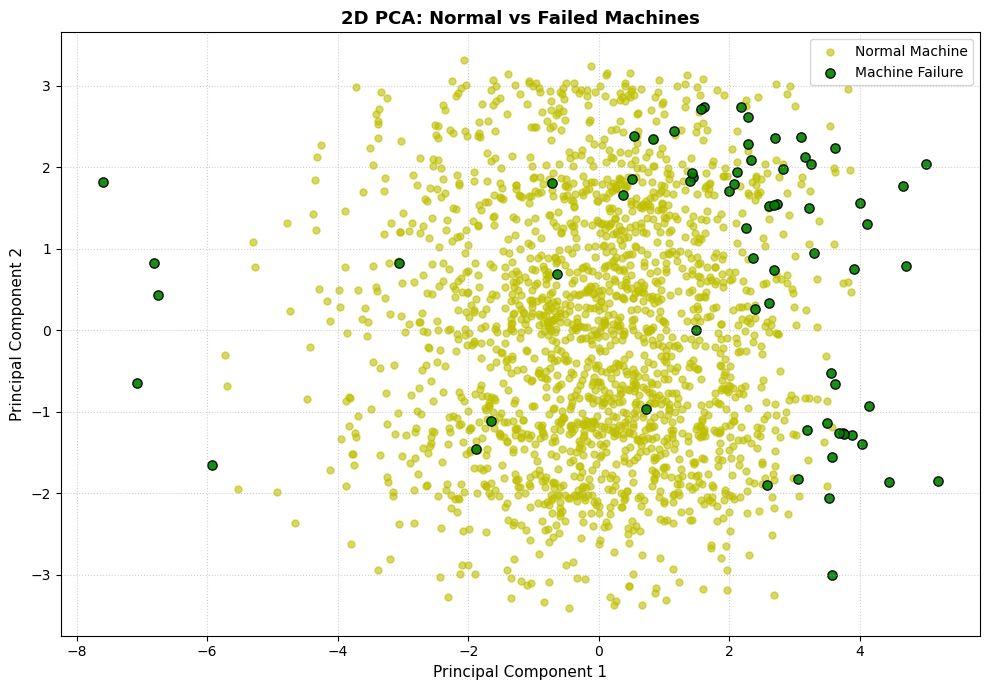

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[y_test == 0, 0], X_pca[y_test == 0, 1],color='y', alpha=0.6, label='Normal Machine', s=25)
plt.scatter(X_pca[y_test == 1, 0], X_pca[y_test == 1, 1],color='g', alpha=0.9, label='Machine Failure', s=45, edgecolor='black')
plt.title('2D PCA: Normal vs Failed Machines', fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=11)
plt.ylabel('Principal Component 2', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Predictive Modeling & Optimization

In [16]:
#starting with logistic regression
lr_model=LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled,y_train)

y_pred_lr=lr_model.predict(X_test_scaled)

lr_accuracy=accuracy_score(y_test,y_pred_lr)
print(f"Logistic Regression Accuracy score: {lr_accuracy}")

lr_recall=recall_score(y_test,y_pred_lr)
print(f"Logistic Regression Recall score: {lr_recall}")


Logistic Regression Accuracy score: 0.9675
Logistic Regression Recall score: 0.17647058823529413


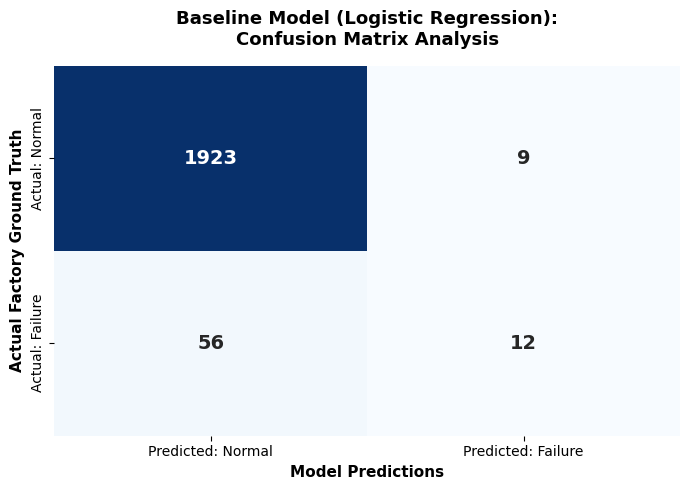

In [17]:
y_pred_log_reg = lr_model.predict(X_test_scaled)
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: Normal', 'Predicted: Failure'],
            yticklabels=['Actual: Normal', 'Actual: Failure'],
            annot_kws={'size': 14, 'fontweight': 'bold'})

plt.title('Baseline Model (Logistic Regression):\nConfusion Matrix Analysis', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Actual Factory Ground Truth', fontsize=11, fontweight='bold')
plt.xlabel('Model Predictions', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Observation: 

High accuracy is misleading due to severe class imbalance (3.4% failure rate) as shown in graph of machine failure distribution. Shifting focus to Recall to catch actual breakdowns.

In [18]:
rf_model=RandomForestClassifier(class_weight='balanced',random_state=42)
rf_model.fit(X_train_scaled,y_train)
y_pred_rf=rf_model.predict(X_test_scaled)
print(f"Random Forest Accuracy score: {accuracy_score(y_test,y_pred_rf)}")
print(f"Random Forest Recall score: {recall_score(y_test,y_pred_rf)}")


Random Forest Accuracy score: 0.99
Random Forest Recall score: 0.7352941176470589


In [19]:
param_grid = {'n_estimators': [100, 200],      
    'max_depth': [10, 15, None],       
    'min_samples_split': [2, 5]}
grid_search = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='recall',  
    cv=3,               
    n_jobs=-1,          
    verbose=2)
grid_search.fit(X_train_scaled, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Grid Search Cross-Validation Recall: {grid_search.best_score_ * 100:.2f}%")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Grid Search Cross-Validation Recall: 79.34%


In [20]:
#Finding best tuned model
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)
print("--- TUNED RANDOM FOREST TEST RESULTS ---")
print(f"Tuned Random Forest Accuracy Score: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print(f"Final Optimized Random Forest Test Recall: {recall_score(y_test, y_pred_tuned) * 100:.2f}%")

--- TUNED RANDOM FOREST TEST RESULTS ---
Tuned Random Forest Accuracy Score: 99.20%
Final Optimized Random Forest Test Recall: 79.41%


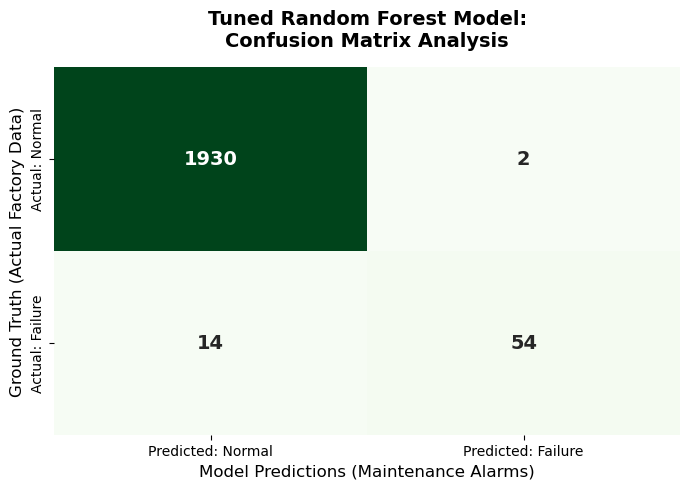

In [21]:
#Generating the confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted: Normal', 'Predicted: Failure'],
            yticklabels=['Actual: Normal', 'Actual: Failure'],
            annot_kws={'size': 14, 'fontweight': 'bold'})
plt.title('Tuned Random Forest Model:\nConfusion Matrix Analysis', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Ground Truth (Actual Factory Data)', fontsize=12)
plt.xlabel('Model Predictions (Maintenance Alarms)', fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
#Applying XGBOOST model
imbalance_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
xgb_model = XGBClassifier(
    scale_pos_weight=imbalance_ratio, 
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
print("--- XGBOOST MODEL RESULTS ---")
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"XGBoost Recall Score: {recall_score(y_test, y_pred_xgb) * 100:.2f}%")

--- XGBOOST MODEL RESULTS ---
XGBoost Accuracy: 99.10%
XGBoost Recall Score: 82.35%


In [23]:
#Tuning XGBOOST for best results
xgb_param_grid = {
    'learning_rate': [0.01, 0.1],   
    'max_depth': [3, 5, 7],      
    'n_estimators': [100, 200]      
}
imbalance_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=42, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    scoring='recall', 
    cv=3,               
    n_jobs=-1,         
    verbose=2
)
xgb_grid_search.fit(X_train_scaled, y_train)
print("\n--- XGBOOST GRID SEARCH RESULTS ---")
print(f"Best Tuned Parameters: {xgb_grid_search.best_params_}")
print(f"Best Tuning Cross-Val Recall: {xgb_grid_search.best_score_ * 100:.2f}%")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- XGBOOST GRID SEARCH RESULTS ---
Best Tuned Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best Tuning Cross-Val Recall: 93.36%


In [24]:
# Extracting best tuned XGBOOST model
best_xgb_model = xgb_grid_search.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test_scaled)
print("--- TUNED XGBOOST FINAL TEST RESULTS ---")
print(f"Optimized Accuracy Score: {accuracy_score(y_test, y_pred_xgb_tuned) * 100:.2f}%")
print(f"Optimized Final Recall Score: {recall_score(y_test, y_pred_xgb_tuned) * 100:.2f}%")

--- TUNED XGBOOST FINAL TEST RESULTS ---
Optimized Accuracy Score: 93.70%
Optimized Final Recall Score: 92.65%


## 5. Model Evaluation & Key Results

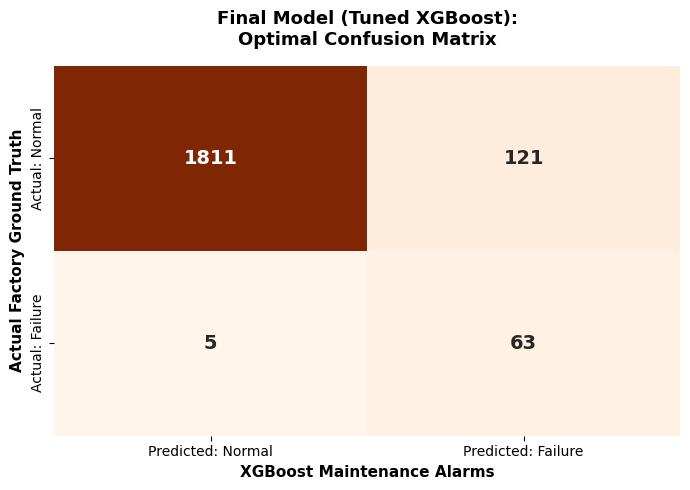

In [25]:
# Confusion matrix of optimized XGBOOST model
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted: Normal', 'Predicted: Failure'],
            yticklabels=['Actual: Normal', 'Actual: Failure'],
            annot_kws={'size': 14, 'fontweight': 'bold'})

plt.title('Final Model (Tuned XGBoost):\nOptimal Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Actual Factory Ground Truth', fontsize=11, fontweight='bold')
plt.xlabel('XGBoost Maintenance Alarms', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

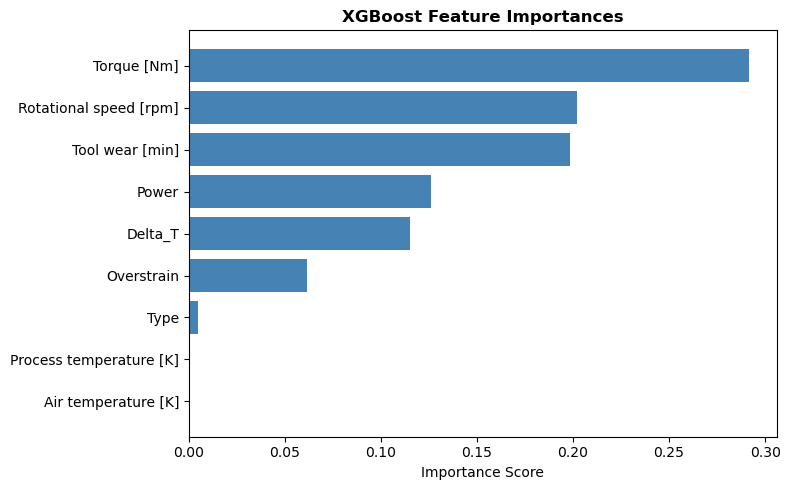

In [26]:
feat_names = X.columns.tolist()
importances = best_xgb_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('XGBoost Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Torque, Rotational Speed, and Tool Wear are the top 3 failure drivers (~70% of 
predictive power combined). Notably, engineered features **Power** and **Delta_T** 
outperform raw temperature readings — confirming that domain-driven feature 
engineering added real predictive signal. Air and Process temperature alone 
are near-irrelevant; it's their *difference* that matters.

## Model Comparison Summary

In [27]:
#Model Comparison results
results = {
    'Model': ['Logistic Regression', 'Random Forest', 
              'Tuned Random Forest', 'XGBoost', 'Tuned XGBoost'],
    'Accuracy (%)': [96.75, 99.00, 99.20, 99.10, 93.70],
    'Recall (%)': [17.65, 73.53, 79.41, 82.35, 92.65]
}
df_results = pd.DataFrame(results)
df_results.style \
    .format({'Accuracy (%)': '{:.2f}', 'Recall (%)': '{:.2f}'}) \
    .highlight_max(subset=['Recall (%)'], color='lightgreen') \
    .highlight_max(subset=['Accuracy (%)'], color='lightyellow') \
    .set_caption('Model Performance Comparison')
display(df_results)

,Model,Accuracy (%),Recall (%)
0,Logistic Regression,96.75,17.65
1,Random Forest,99.00,73.53
2,Tuned Random Forest,99.20,79.41
3,XGBoost,99.10,82.35
4,Tuned XGBoost,93.70,92.65


## Final Conclusion

The tuned XGBoost model achieves 92.65% recall (93 out of 100 real failures caught) with 93.70% accuracy. This comes with a deliberate tradeoff: approximately 121 false alarms per 2,000 machines (~6.3% of normal machines flagged unnecessarily). In industrial maintenance, this tradeoff is intentional — missing a real failure causing unplanned downtime is far more costly than an unnecessary inspection.